In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# **I. EDA đơn biến**

## **1. EDA bảng sales**

In [3]:
sales = pd.read_csv('../../sales.csv')


In [4]:
sales


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [ ]:
sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB


In [ ]:
sales.shape


(3833, 3)

In [ ]:
sales.dtypes


Date        object
Revenue    float64
COGS       float64
dtype: object

In [ ]:
sales['Date'] = pd.to_datetime(sales['Date'], format='%Y-%m-%d')


In [ ]:
sales.describe()


,Date,Revenue,COGS
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06


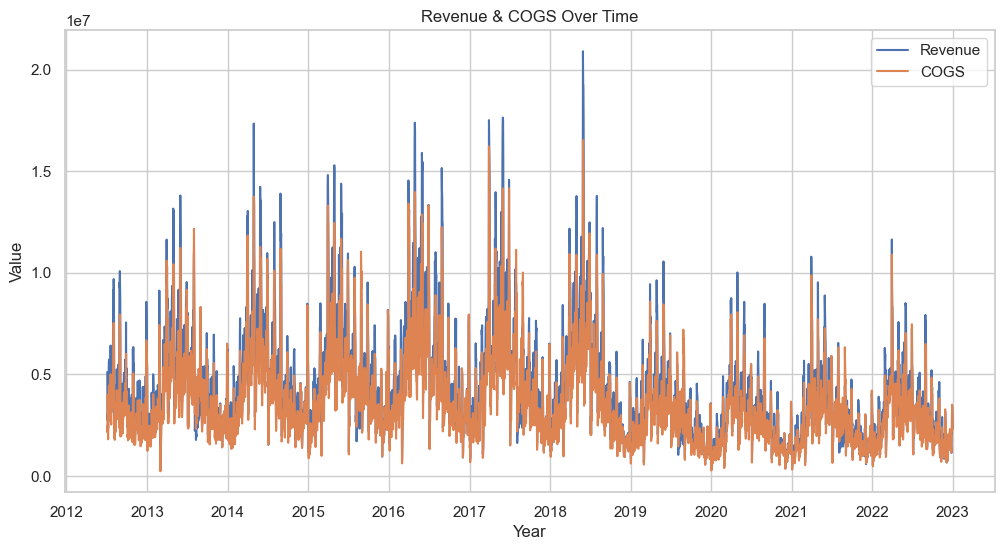

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(sales['Date'], sales['Revenue'], label='Revenue')
plt.plot(sales['Date'], sales['COGS'], label='COGS')

ax = plt.gca()

# Chỉ hiển thị theo năm
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Revenue & COGS Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()

plt.show()


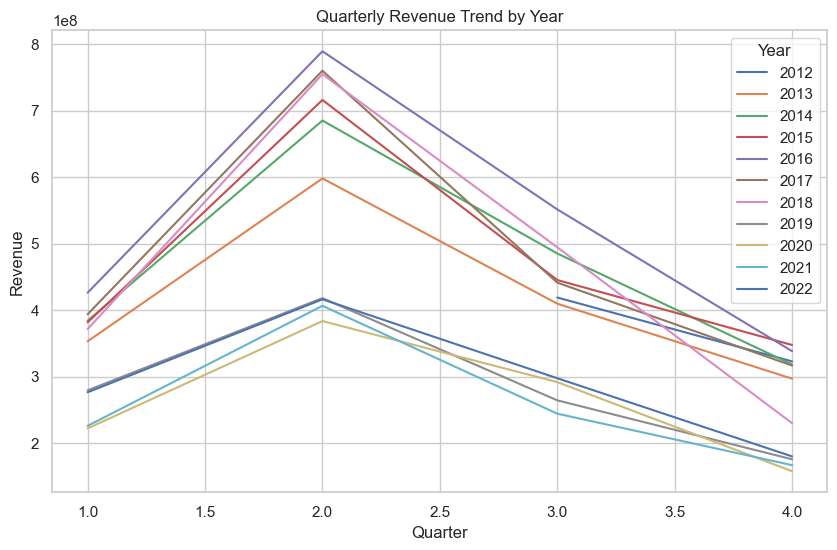

In [ ]:
sales['Year'] = sales['Date'].dt.year
sales['Quarter'] = sales['Date'].dt.quarter

pivot = sales.pivot_table(
    index='Quarter',
    columns='Year',
    values='Revenue',
    aggfunc='sum'
)

pivot.plot(figsize=(10,6))

plt.title('Quarterly Revenue Trend by Year')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

plt.show()


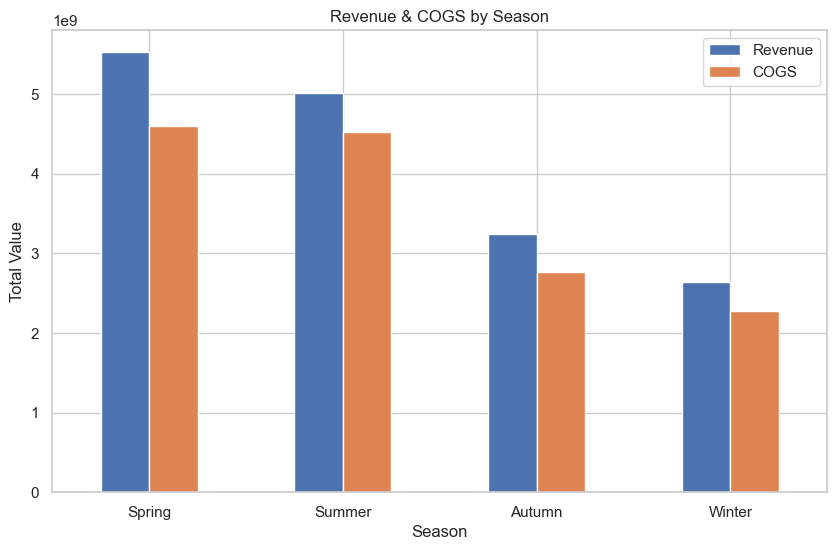

In [ ]:
def get_season(month):
    if month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    elif month in [9,10,11]:
        return 'Autumn'
    else:
        return 'Winter'

sales['Season'] = sales['Date'].dt.month.apply(get_season)

seasonal = sales.groupby('Season')[['Revenue','COGS']].sum()

# Sắp xếp đúng thứ tự mùa
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
seasonal = seasonal.reindex(season_order)

seasonal.plot(kind='bar', figsize=(10,6))

plt.title('Revenue & COGS by Season')
plt.xlabel('Season')
plt.ylabel('Total Value')

plt.xticks(rotation=0)
plt.show()


In [ ]:
# sort theo thời gian
sales = sales.sort_values('Date')

# tạo profit
sales['Profit'] = sales['Revenue'] - sales['COGS']


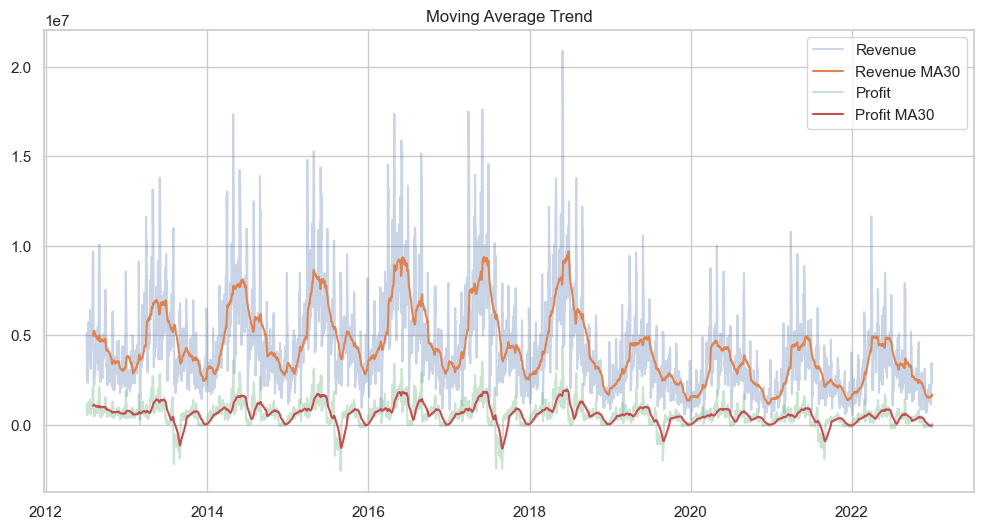

In [ ]:
# 30 ngày (có thể đổi 7, 90 tùy bài toán)
sales['Revenue_MA30'] = sales['Revenue'].rolling(window=30).mean()
sales['COGS_MA30'] = sales['COGS'].rolling(window=30).mean()
sales['Profit_MA30'] = sales['Profit'].rolling(window=30).mean()

plt.figure(figsize=(12,6))

plt.plot(sales['Date'], sales['Revenue'], alpha=0.3, label='Revenue')
plt.plot(sales['Date'], sales['Revenue_MA30'], label='Revenue MA30')

plt.plot(sales['Date'], sales['Profit'], alpha=0.3, label='Profit')
plt.plot(sales['Date'], sales['Profit_MA30'], label='Profit MA30')

plt.legend()
plt.title('Moving Average Trend')
plt.show()


In [ ]:
import seaborn as sns


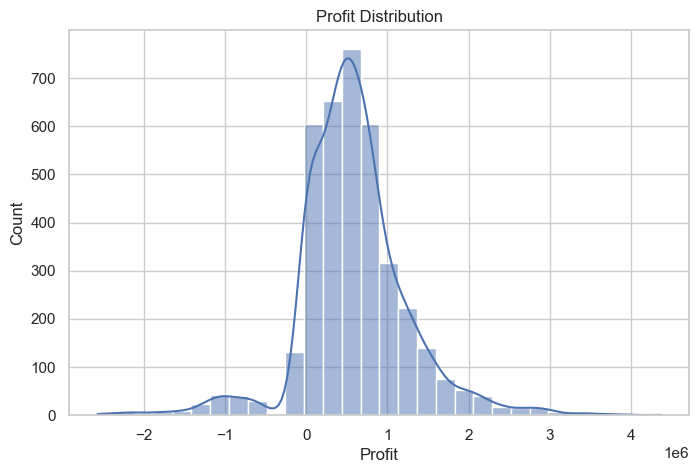

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(sales['Profit'], bins=30, kde=True)

plt.title('Profit Distribution')
plt.show()


## **2. EDA bảng products**

In [ ]:
products = pd.read_csv('products.csv')


In [ ]:
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [ ]:
products.describe()


,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


In [ ]:
products


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406
...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500


In [ ]:
category_count = products.groupby('category').size().reset_index(name='count')
print(category_count)


     category  count
0      Casual    201
1        GenZ    148
2     Outdoor    743
3  Streetwear   1320


In [ ]:
segment_count = products.groupby('segment').size().reset_index(name='count')
print(segment_count)


       segment  count
0   Activewear    598
1  All-weather    169
2     Balanced    306
3     Everyday    405
4  Performance    347
5      Premium    177
6     Standard    262
7       Trendy    148


In [ ]:
cat_seg_count = (
    products
    .groupby(['category', 'segment'])
    .size()
    .reset_index(name='count')
)

print(cat_seg_count)


     category      segment  count
0      Casual   Activewear     32
1      Casual  All-weather    169
2        GenZ       Trendy    148
3     Outdoor   Activewear    566
4     Outdoor      Premium    177
5  Streetwear     Balanced    306
6  Streetwear     Everyday    405
7  Streetwear  Performance    347
8  Streetwear     Standard    262


In [ ]:
pivot = pd.pivot_table(
    products,
    index='category',
    columns='segment',
    aggfunc='size',
    fill_value=0
)

pivot


segment,Activewear,All-weather,Balanced,Everyday,Performance,Premium,Standard,Trendy
category,,,,,,,,
Casual,32,169,0,0,0,0,0,0
GenZ,0,0,0,0,0,0,0,148
Outdoor,566,0,0,0,0,177,0,0
Streetwear,0,0,306,405,347,0,262,0


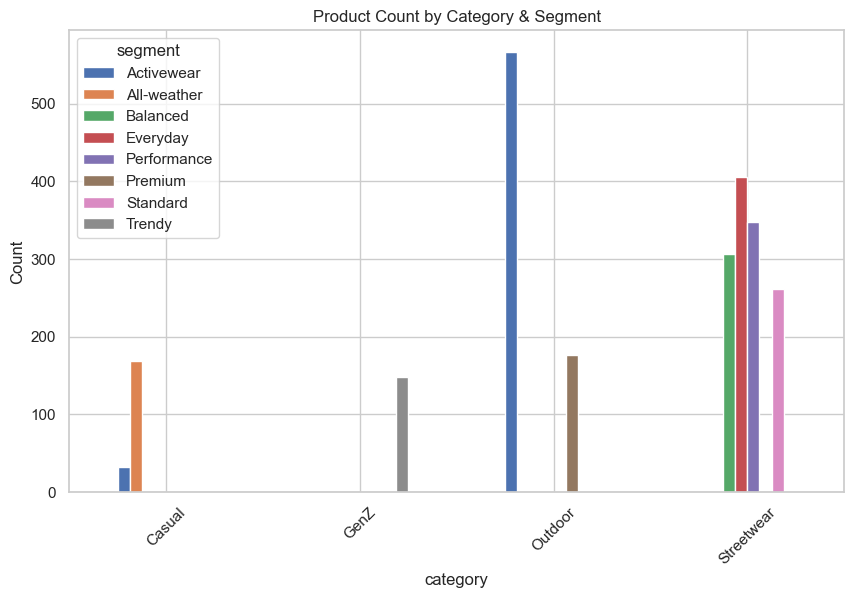

In [ ]:
pivot.plot(kind='bar', figsize=(10,6))
plt.title('Product Count by Category & Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [6]:
import pandas as pd

sales['Date'] = pd.to_datetime(sales['Date'])


In [ ]:
sales


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [9]:
sales['day_of_week'] = sales['Date'].dt.day_name()   # Monday, Tuesday...
sales['month'] = sales['Date'].dt.month              # 1 → 12


In [10]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales['day_of_week'] = pd.Categorical(sales['day_of_week'], categories=order, ordered=True)


In [ ]:
dow_avg = sales.groupby('day_of_week')[['Revenue', 'COGS']].mean()


/var/folders/36/khn_y8zn7qqflczfpst8cbfc0000gn/T/ipykernel_55017/2644202341.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dow_avg = sales.groupby('day_of_week')[['Revenue', 'COGS']].mean()


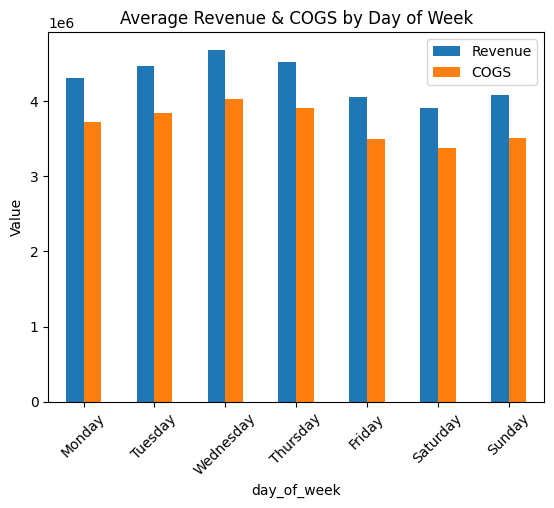

In [13]:
import matplotlib.pyplot as plt

dow_avg.plot(kind='bar')
plt.title('Average Revenue & COGS by Day of Week')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()
